<script src="/course_model/toc.js"></script>

# Natural Language Processing (NLP) with Python

Natural Language Processing (NLP) teaches computers to work with text. NLP turns messy text (course comments, survey responses, reviews, emails) into numbers you can model.

**Outcomes**:
- Explain what NLP does in a data analysis workflow
- Load and explore a small text dataset in IPython
- Clean and preprocess raw text (lowercasing, removing punctuation, stopwords)
- Turn text into numeric features using TF-IDF
- Build and evaluate a simple text classifier
- Do a basic unsupervised topic exploration with clustering and PCA

**Examples**:
- [db of happyness](https://github.com/megagonlabs/HappyDB)
- [Vis](https://flowingdata.com/2021/07/29/counting-happiness/)
- [Vis2](https://flowingdata.com/2018/06/21/what-makes-people-the-most-happy/)
- [Vis3](https://pudding.cool/2026/02/happy-map/)

**Links**
- [newsgroup template](newsgroup.ipynb) 
- [template](template.ipynb) and [datafile](sms_spam.csv)

## Algorithm Overview

Key Concepts:
- NLP turns text into numbers for modeling.
- Text requires preprocessing 
    - Lowercasing and removing removing punctuation are easy methods for removing noise.
    - Stopwords (commonly used words like "the", "and", "is") are often removed to reduce noise.
- TF-IDF is a common method to convert text into tables of numbers (one row per document, one column per word).
    - TF-IDF weights words by importance, reducing the impact of common words. This is often better for modeling.
- NLP can be used for supervised and unsupervised learning
    - Supervised models may include building a classifier with logistic regression to predict spam vs. non-spam emails.
    - Unsupervised models may include clustering documents to find topics.

Problems:
- Text data is often messy and unstructured, requiring significant preprocessing.
- High dimensionality: Text data can lead to a large number of features (words), which can complicate modeling.
- Context and semantics: Capturing the meaning of words and phrases can be challenging, especially with polysemy (words with multiple meanings) and synonyms.
- Computational resources: Processing large text datasets can be resource-intensive.

Interpretation:
- Overall model:
    - For supervised learning, we can evaluate model performance using metrics like accuracy, precision, recall, and F1-score for classification tasks.
    - For unsupervised learning, we can assess clustering quality using metrics like inertia 

### Step 1: Sample Course Evaluation

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

data = [
    ("The assignments were really helpful and the examples were clear.", 1),
    ("Too much homework and unclear instructions on most projects.", 0),
    ("I loved the real-world data sets we used in class.", 1),
    ("Lectures were disorganized and it was hard to follow.", 0),
    ("Great balance of theory and practice, very engaging instructor.", 1),
    ("The grading rubric was confusing and feedback was limited.", 0),
    ("I learned a lot about Python and data analysis in this course.", 1),
    ("The pace was too fast and slides were not posted on time.", 0),
    ("Very practical course, I feel more confident analyzing data.", 1),
    ("Group project instructions were vague and deadlines were unrealistic.", 0),
    ("The examples made complex ideas much easier to understand.", 1),
    ("Instructions for several assignments were unclear and hard to follow.", 0),
    ("I appreciated the real-life applications woven into each lecture.", 1),
    ("The workload felt excessive compared to other courses at this level.", 0),
    ("The instructor explained things clearly and supported us well.", 1),
    ("Deadlines were too close together and caused unnecessary stress.", 0),
    ("Class discussions were engaging and helped reinforce key concepts.", 1),
    ("It was difficult to know what was expected on the midterm.", 0),
    ("Great mix of coding demonstrations and conceptual teaching.", 1),
    ("The slides were often posted late, making it hard to prepare.", 0),
    ("I really liked how approachable the instructor was.", 1),
    ("A lot of confusing grading standards across assignments.", 0),
    ("The projects were challenging in a good way and taught me a lot.", 1),
    ("Course expectations shifted too often and caused confusion.", 0),
    ("I liked the hands-on approach to learning Python.", 1),
    ("Feedback took too long to return and wasn’t very detailed.", 0),
    ("Loved the interactive notebooks used in class!", 1),
    ("The textbook was outdated and not helpful.", 0),
    ("Office hours were extremely helpful for understanding tricky topics.", 1),
    ("Some quizzes covered material we never discussed.", 0),
    ("Great pacing and very clear explanations.", 1),
    ("The instructor talked too fast and skipped important steps.", 0),
    ("Assignments pushed me to think critically and apply what I learned.", 1),
    ("Too many last-minute announcements made planning difficult.", 0),
    ("I enjoyed the practical examples involving real datasets.", 1),
    ("Group work was disorganized and uneven across teams.", 0),
    ("The instructor encouraged questions and created a welcoming environment.", 1),
    ("Lecture recordings were frequently missing or incomplete.", 0),
    ("Clear expectations and fair grading throughout the course.", 1),
    ("The project instructions were vague and frustrating.", 0),
    ("Very supportive instructor who wanted us to succeed.", 1),
    ("Assignments were overloaded with unnecessary steps.", 0),
    ("Class activities helped me retain the material better.", 1),
    ("The exam format didn’t match what we practiced in class.", 0),
    ("I learned to write better code because of this course.", 1),
    ("Several assignments required tools we never covered.", 0),
    ("The instructor broke concepts down into manageable pieces.", 1),
    ("The lecture slides were poorly formatted and hard to read.", 0),
    ("Great environment for building confidence in data analysis.", 1),
    ("Class often felt rushed and lacked structure.", 0),
    ("The examples were relevant and connected well to real problems.", 1),
    ("The grading rubric was not followed consistently.", 0),
    ("The course helped me feel more capable analyzing data.", 1),
    ("There were frequent technical issues during lectures.", 0),
    ("The instructor used humor and stories that made class enjoyable.", 1),
    ("Assignments required too much time for the number of credits.", 0),
    ("Material was explained step-by-step and easy to follow.", 1),
    ("Course organization was confusing and inconsistent.", 0),
    ("Hands-on labs were the best part of this class.", 1),
    ("The final exam felt unfair and didn’t reflect what we learned.", 0),
    ("I liked how the instructor connected Python to real careers.", 1),
    ("Syllabus didn’t match what happened during the semester.", 0),
    ("The instructor checked in often to make sure we understood.", 1),
    ("Poor communication about changes to deadlines.", 0),
    ("Amazing job making complex topics feel intuitive.", 1),
    ("Too many required platforms and tools to keep track of.", 0),
    ("The coding demos were clear and easy to replicate.", 1),
    ("The rubric never explained how partial credit was assigned.", 0),
    ("Very motivating instructor who clearly cared.", 1),
    ("The homework system didn’t save progress reliably.", 0),
    ("The course tied theory and application together well.", 1),
    ("Daily logistics like attendance and make-ups were unclear.", 0),
    ("Great examples that helped solidify the material.", 1),
    ("Lectures often went off-topic and wasted time.", 0),
    ("I gained meaningful, practical skills from this class.", 1),
    ("It was hard to know what material would be on the quizzes.", 0),
    ("The instructor gave helpful, specific feedback.", 1),
    ("The workload was inconsistent from week to week.", 0),
    ("I appreciated the supportive classroom environment.", 1),
    ("Recordings were unreliable and cut off mid-lecture.", 0),
    ("The interactive coding sessions were very useful.", 1),
    ("Many tasks felt repetitive rather than educational.", 0),
    ("The course helped me become confident writing Python code.", 1),
    ("Deadlines were scheduled at unreasonable times.", 0),
    ("The instructor’s explanations made everything make sense.", 1),
    ("Important announcements were easy to miss.", 0),
    ("The design of the projects helped me understand the material deeply.", 1),
    ("Class often started late and felt unprepared.", 0),
    ("The mix of theory and hands-on work was excellent.", 1),
    ("The grading process felt random and inconsistent.", 0),
    ("Good pacing, and the instructor checked for understanding often.", 1),
    ("Assignments required tools not supported on my computer.", 0),
    ("This was one of the most practical courses I've taken.", 1),
    ("There was little explanation about how grades were computed.", 0),
    ("Clear lectures with helpful real-world examples.", 1),
    ("Homework feedback did not explain what to improve.", 0),
    ("The instructor made time for every student who needed help.", 1),
    ("The LMS was disorganized with missing files.", 0),
]

df = pd.DataFrame(data, columns=["comment", "sentiment"])  # 1=positive, 0=negative
df


,comment,sentiment
0,The assignments were really helpful and the ex...,1
1,Too much homework and unclear instructions on ...,0
2,I loved the real-world data sets we used in cl...,1
3,Lectures were disorganized and it was hard to ...,0
4,"Great balance of theory and practice, very eng...",1
...,...,...
93,There was little explanation about how grades ...,0
94,Clear lectures with helpful real-world examples.,1
95,Homework feedback did not explain what to impr...,0
96,The instructor made time for every student who...,1


### Step 2: Data Cleanup

NLP usually starts with normalizing the text:

- Lowercasing (“The” and “the” become the same)
- Removing punctuation
- Optionally removing stopwords (“and”, “the”, “of”)
- Optionally stemming/lemmatizing (turning “running”, “runs” → “run”)

Here we’ll use scikit-learn’s built-in preprocessing. It can handle:
- Lowercasing by default
- Tokenization (splitting text into words)
- Removing English stopwords if we ask it to

In [4]:
import re

def basic_clean(text: str) -> str:
    # Lowercase
    text = text.lower()
    # Remove anything that's not a letter or space
    text = re.sub(r"[^a-z\s]", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_comment"] = df["comment"].apply(basic_clean)
df[["comment", "clean_comment"]]

df

,comment,sentiment,clean_comment
0,The assignments were really helpful and the ex...,1,the assignments were really helpful and the ex...
1,Too much homework and unclear instructions on ...,0,too much homework and unclear instructions on ...
2,I loved the real-world data sets we used in cl...,1,i loved the realworld data sets we used in class
3,Lectures were disorganized and it was hard to ...,0,lectures were disorganized and it was hard to ...
4,"Great balance of theory and practice, very eng...",1,great balance of theory and practice very enga...
...,...,...,...
93,There was little explanation about how grades ...,0,there was little explanation about how grades ...
94,Clear lectures with helpful real-world examples.,1,clear lectures with helpful realworld examples
95,Homework feedback did not explain what to impr...,0,homework feedback did not explain what to improve
96,The instructor made time for every student who...,1,the instructor made time for every student who...


### Step 3: TF-IDF – focus on informative words

A more traditional approach (such as Bag-of-Words) counts treat all words equally. TF-IDF (Term Frequency–Inverse Document Frequency) down-weights very common words and up-weights words that are more distinctive. 

Intuition:
- “course” might appear in almost every comment → not very informative.
- “disorganized” or “engaging” appear less often → more informative signals.

Example:

Documents:

- “Course is great”
- “Course is hard”
- “Course is hard”
- “Wow”

Vocabulary used: course, great, hard, wow

*Count matrix:*

| Document        | course | great | hard | wow |
| --------------- | ------ | ----- | ---- | --- |
| Course is great | 1      | 1     | 0    | 0   |
| Course is hard  | 1      | 0     | 1    | 0   |
| Course is hard  | 1      | 0     | 1    | 0   |
| Wow             | 0      | 0     | 0    | 1   |


*TF-IDF matrix:*


| Document        | course | great | hard  | wow   |
| --------------- | ------ | ----- | ----- | ----- |
| Course is great | 0.463  | 1.000 | 0.000 | 0.000 |
| Course is hard  | 0.463  | 0.000 | 0.886 | 0.000 |
| Course is hard  | 0.463  | 0.000 | 0.886 | 0.000 |
| Wow             | 0.000  | 0.000 | 0.000 | 1.000 |

Note that the values are rounded for readability. The pattern is what's important: common words like "course" get discounted.




array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(98, 283))

Training accuracy: 1.0
Test accuracy: 0.8666666666666667


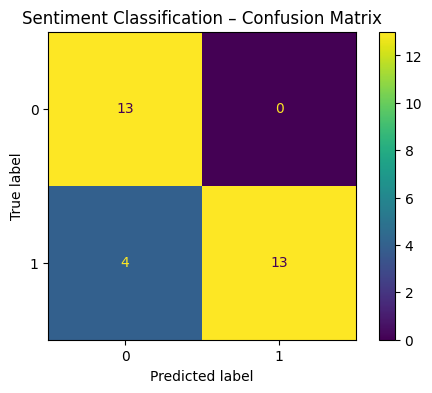

In [9]:
# Prepare data for modeling
X = df["clean_comment"]
y = df["sentiment"]

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(stop_words="english")
X_tfidf = tfidf_vectorizer.fit_transform(df["clean_comment"])

# Do the same train/test split and classification with TF-IDF features
# Use logistical regression again and compare accuracy.
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.3, random_state=42
)

clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train, y_train)

# How well does it do on the training set?
y_train_pred = clf_tfidf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training accuracy: {train_acc}")

# How well does it do on the *test* set?
y_pred = clf_tfidf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_acc}")

# Confusion Matrix for test set
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_tfidf.classes_)
disp.plot()
plt.title("Sentiment Classification – Confusion Matrix")
plt.show()


### Step 4: Clustering to explore topics

What if you don’t have labels?
You can still use NLP to group documents with similar content.

We’ll use K-Means clustering on the TF-IDF matrix:
- Input: TF-IDF features
- Output: Cluster assignments (e.g., “complaints about workload” vs “praise for instructor”)

In [10]:
k = 2  # we suspect there might be "positive" vs "negative"-like groups
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_tfidf)

df["cluster"] = clusters
df[["comment", "cluster"]]


,comment,cluster
0,The assignments were really helpful and the ex...,0
1,Too much homework and unclear instructions on ...,1
2,I loved the real-world data sets we used in cl...,0
3,Lectures were disorganized and it was hard to ...,0
4,"Great balance of theory and practice, very eng...",0
...,...,...
93,There was little explanation about how grades ...,0
94,Clear lectures with helpful real-world examples.,0
95,Homework feedback did not explain what to impr...,0
96,The instructor made time for every student who...,0


In [11]:
terms = tfidf_vectorizer.get_feature_names_out()
centers = kmeans.cluster_centers_

for cluster_id in range(k):
    print(f"\nCluster {cluster_id}")
    center = centers[cluster_id]
    top_idx = center.argsort()[::-1][:10]
    print([terms[i] for i in top_idx])



Cluster 0
['instructor', 'class', 'course', 'assignments', 'material', 'examples', 'felt', 'helped', 'clear', 'helpful']

Cluster 1
['unclear', 'instructions', 'projects', 'homework', 'follow', 'hard', 'makeups', 'attendance', 'logistics', 'daily']


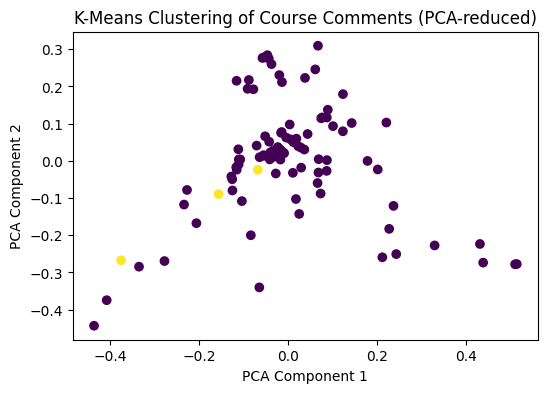

In [12]:
# Visualize clusters using PCA (2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_tfidf.toarray())
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("K-Means Clustering of Course Comments (PCA-reduced)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()